In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import re
import seaborn as sns
#Importing CSV files
path = '/Users/haleybrewster/LabCode/csv'

# RFT COEFF vs. x-displacement

Measuring how far RHex moves for different stiffness values. Comparing how the payload changes displacement. All other variables are held constant

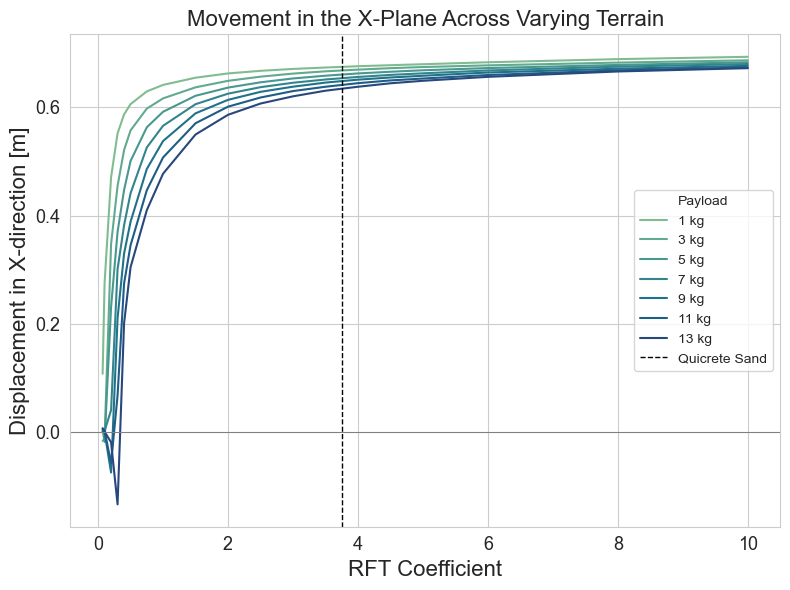

In [2]:
payload_list = [1,3,5,7,9,11,13]

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")
colors_01 = sns.color_palette("crest", n_colors=len(payload_list))

for payload,color in zip (payload_list,colors_01):
    pl_df = glob.glob(os.path.join(path, f"*payload_{payload}.csv"))
    results_pl = []
    for rft in pl_df:
        rft_df = pd.read_csv(rft)
        x_pos = rft_df['X [m]']
        #taking last integer in the df and subtracting it against the first
        x_displacement = x_pos.iloc[-1] - x_pos.iloc[0]

        #pairing displacement w/ stiffness values
        filename = os.path.basename(rft)
        numbers = re.findall(r"\d+\.?\d*",filename)
        stiffness = float(numbers[0])
        results_pl.append((stiffness , x_displacement , filename))

    # optional block for organizing the legend in order of stiffness
    results_pl.sort(key=lambda x: x[0])   
    stiffnesses = [r[0] for r in results_pl]
    displacements = [r[1] for r in results_pl]
    labels = [r[2] for r in results_pl]

    sns.lineplot(x=stiffnesses,y=displacements,linewidth=1.5,label=f"{payload} kg",color = color)
    
# stiffness coefficient value of Quikrete Play Sand as listed in https://arxiv.org/pdf/2606.19504
plt.axvline(x=3.75, color='black', linestyle='--', linewidth=1, label='Quicrete Sand')
plt.axhline(y=0, color='grey', linestyle='-', linewidth=0.75)

plt.xlabel("RFT Coefficient" , fontsize = 16)
plt.ylabel("Displacement in X-direction [m]" , fontsize = 16)
plt.title("Movement in the X-Plane Across Varying Terrain" , fontsize = 16)
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.legend(title="Payload")
plt.grid(True)
plt.tight_layout()
plt.show()

# Payload vs. x-displacement

Measuring how far RHex with different payloads. Analyzing across multiple RFT coefficient values. All other variables are held constant

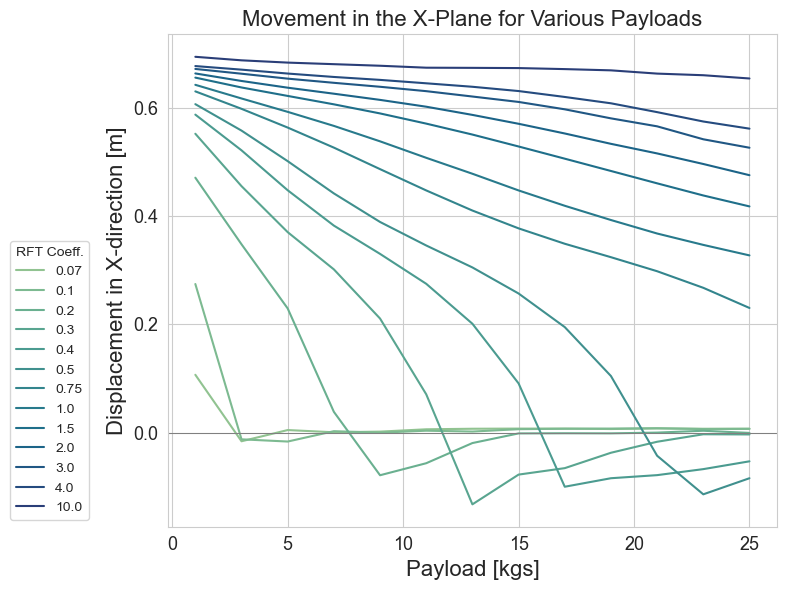

In [7]:
coeff = [0.07,0.10,0.20,0.30,0.40,0.50,0.75,1.00,1.50,2.00,3.00,4.00,10.00]

plt.figure(figsize=(8, 6))
colors_02 = sns.color_palette("crest", n_colors=len(coeff))

for z,color in zip(coeff,colors_02):
    stiffness = glob.glob(os.path.join(path, f"*0_rft_{z:.2f}.csv"))
    results_z = []
    for payload in stiffness:
        df = pd.read_csv(payload)
        x_pos = df['X [m]']
        #taking last integer in the df and subtracting it against the first
        x_displacement = x_pos.iloc[-1] - x_pos.iloc[0]

        #pairing displacement w/ stiffness values
        filename = os.path.basename(payload)
        numbers = re.findall(r"\d+\.?\d*",filename)
        pl = float(numbers[0])
        results_z.append((pl , x_displacement , filename))

    # optional block for organizing the legend in order of stiffness
    results_z.sort(key=lambda x: x[0])   
    payloads = [r[0] for r in results_z]
    displacements = [r[1] for r in results_z]
    labels = [r[2] for r in results_z]

    sns.lineplot(x=payloads, y=displacements,linewidth = 1.5,label=f"{z}",color=color)
plt.xlabel("Payload [kgs]" , fontsize = 16)
plt.ylabel("Displacement in X-direction [m]" , fontsize = 16)
plt.title("Movement in the X-Plane for Various Payloads" , fontsize = 16)
plt.legend(title= "RFT Coeff.",loc="lower left",bbox_to_anchor=(-0.27, 0))
plt.axhline(y=0, color='grey', linestyle='-', linewidth=0.75)
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.grid(True)
plt.tight_layout()
plt.show()
#print(stiffness)

# Speed of Step given stance phase vs. Displacement

Measuring how far RHex will move in the x-direction with different step speeds. This will be analyzed over different rft coefficients and payloads

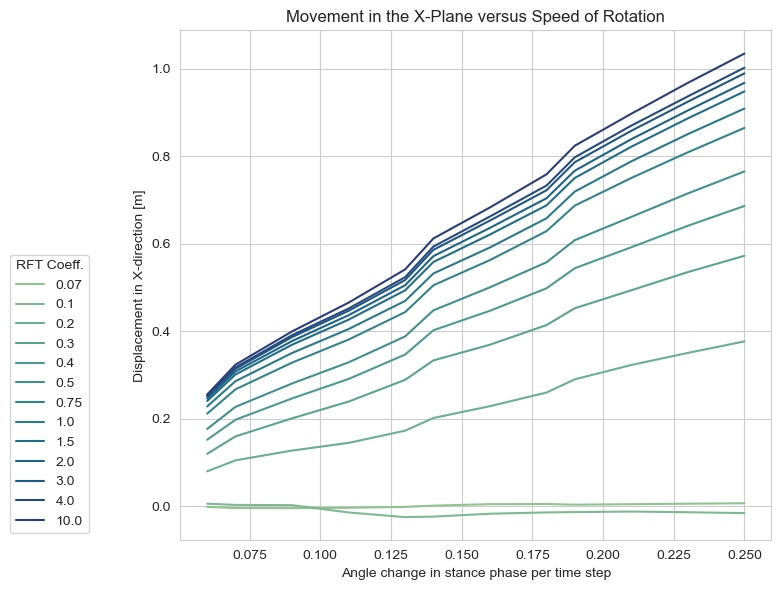

In [4]:
coeff = [0.07,0.10,0.20,0.30,0.40,0.50,0.75,1.00,1.50,2.00,3.00,4.00,10.00]
plt.figure(figsize=(8, 6))
stance_list = [0.05714,0.07428,0.09143,0.108057,0.12571,0.14286,0.16,0.17714,0.19429,0.21143,0.22857,0.24571]

colors_03 = sns.color_palette("crest", n_colors=len(coeff))
for z,cl in zip(coeff,colors_03):
    results_z = []
    for stance in stance_list:
        stance_speed = glob.glob(os.path.join(path, f"*stance_{stance:.2f}_rft_{z:.2f}.csv"))
        for a in stance_speed:
            df = pd.read_csv(a)
            x_pos = df['X [m]']
            #taking last integer in the df and subtracting it against the first
            x_displacement = x_pos.iloc[-1] - x_pos.iloc[0]

            #pairing displacement w/ stiffness values
            filename = os.path.basename(a)
            numbers = re.findall(r"\d+\.?\d*",filename)
            stance_step = float(numbers[0])
            results_z.append((stance_step , x_displacement , filename))

        # optional block for organizing the legend in order of stiffness
    results_z.sort(key=lambda x: x[0])   
    speeds = [r[0] for r in results_z]
    displacements = [r[1] for r in results_z]
    labels = [r[2] for r in results_z]

    sns.lineplot(x=speeds, y=displacements,linewidth = 1.5,label=f"{z}",color=cl)
plt.xlabel("Angle change in stance phase per time step")
plt.ylabel("Displacement in X-direction [m]")
plt.title("Movement in the X-Plane versus Speed of Rotation")
plt.legend(title="RFT Coeff.", loc="lower left",bbox_to_anchor=(-0.3, 0))
plt.grid(True)
plt.tight_layout()
plt.show()

now for differing payloads

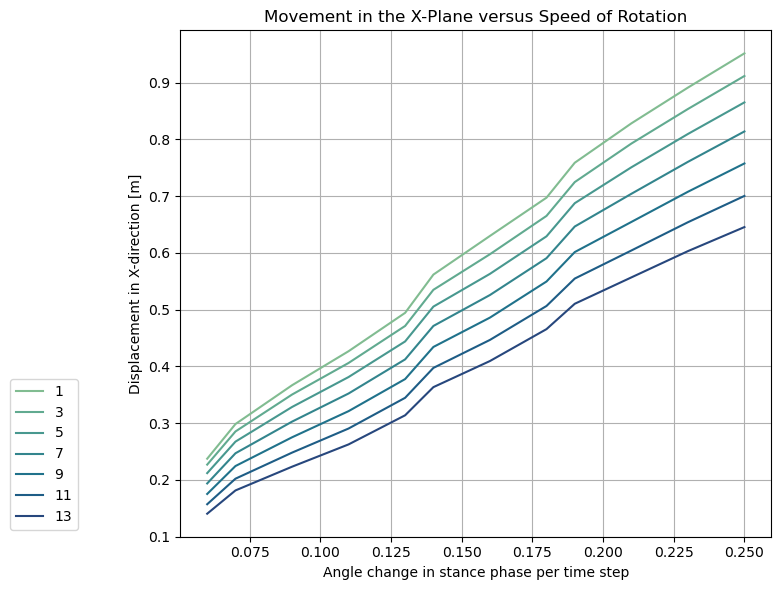

In [3]:
payload_list_02 = [1,3,5,7,9,11,13]
#[1,3,5,7,9,11,13]
plt.figure(figsize=(8, 6))
stance_list = [0.05714,0.07428,0.09143,0.108057,0.12571,0.14286,0.16,0.17714,0.19429,0.21143,0.22857,0.24571]

colors_04 = sns.color_palette("crest", n_colors=len(payload_list_02))
for pl,cl in zip(payload_list_02,colors_04):
    results_pl = []
    for stance in stance_list:
        stance_speed = glob.glob(os.path.join(path, f"*stance_{stance:.2f}_payload_{pl:.2f}.csv"))
        for a in stance_speed:
            df = pd.read_csv(a)
            x_pos = df['X [m]']
            #taking last integer in the df and subtracting it against the first
            x_displacement = x_pos.iloc[-1] - x_pos.iloc[0]

            #pairing displacement w/ stiffness values
            filename = os.path.basename(a)
            numbers = re.findall(r"\d+\.?\d*",filename)
            stance_step = float(numbers[0])
            results_pl.append((stance_step , x_displacement , filename))

        # optional block for organizing the legend in order of stiffness
    results_pl.sort(key=lambda x: x[0])   
    speeds = [r[0] for r in results_pl]
    displacements = [r[1] for r in results_pl]
    labels = [r[2] for r in results_pl]

    sns.lineplot(x=speeds, y=displacements,linewidth = 1.5,label=f"{pl}",color=cl)
plt.xlabel("Angle change in stance phase per time step")
plt.ylabel("Displacement in X-direction [m]")
plt.title("Movement in the X-Plane versus Speed of Rotation")
plt.legend(loc="lower left",bbox_to_anchor=(-0.3, 0))
plt.grid(True)
plt.tight_layout()
plt.show()

We are changing where the stance phase is and seeing how it changes the displacement given an rft of 0.75 and standard stance speeds. with a variety of payloads

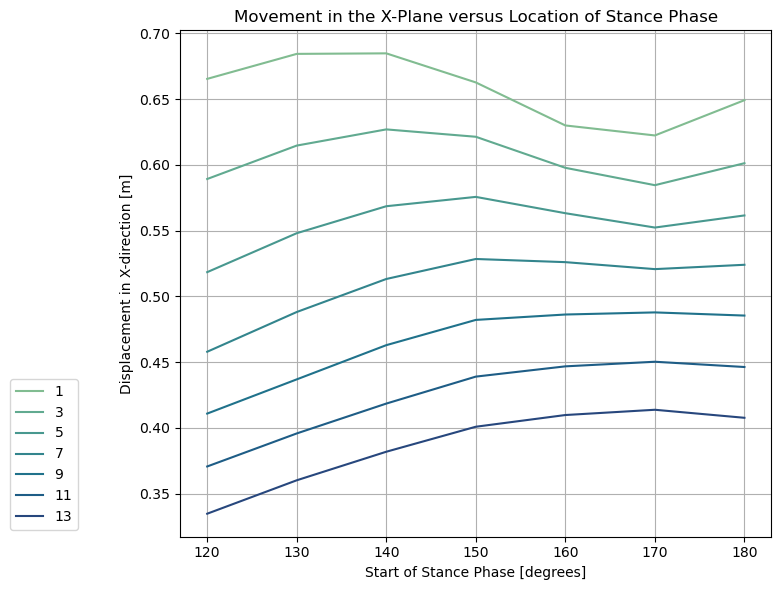

In [16]:
payload_list_03 = [1,3,5,7,9,11,13]
#[1,3,5,7,9,11,13]
plt.figure(figsize=(8, 6))
start_stance = [120,130,140,150,160,170,180]

colors_04 = sns.color_palette("crest", n_colors=len(payload_list_03))
for pl,cl in zip(payload_list_03,colors_04):
    results_pl = []
    for start_angle in start_stance:
        stance_speed = glob.glob(os.path.join(path, f"*start_{start_angle:.2f}_payload_{pl:.2f}.csv"))
        for a in stance_speed:
            df = pd.read_csv(a)
            x_pos = df['X [m]']
            #taking last integer in the df and subtracting it against the first
            x_displacement = x_pos.iloc[-1] - x_pos.iloc[0]

            #pairing displacement w/ stiffness values
            filename = os.path.basename(a)
            numbers = re.findall(r"\d+\.?\d*",filename)
            stance_step = float(numbers[0])
            results_pl.append((stance_step , x_displacement , filename))

        # optional block for organizing the legend in order of stiffness
    results_pl.sort(key=lambda x: x[0])   
    speeds = [r[0] for r in results_pl]
    displacements = [r[1] for r in results_pl]
    labels = [r[2] for r in results_pl]

    sns.lineplot(x=speeds, y=displacements,linewidth = 1.5,label=f"{pl}",color=cl)
plt.xlabel("Start of Stance Phase [degrees]")
plt.ylabel("Displacement in X-direction [m]")
plt.title("Movement in the X-Plane versus Location of Stance Phase")
plt.legend(loc="lower left",bbox_to_anchor=(-0.3, 0))
plt.grid(True)
plt.tight_layout()
plt.show()

now for a given payload of 5kg, and changing the stiffness

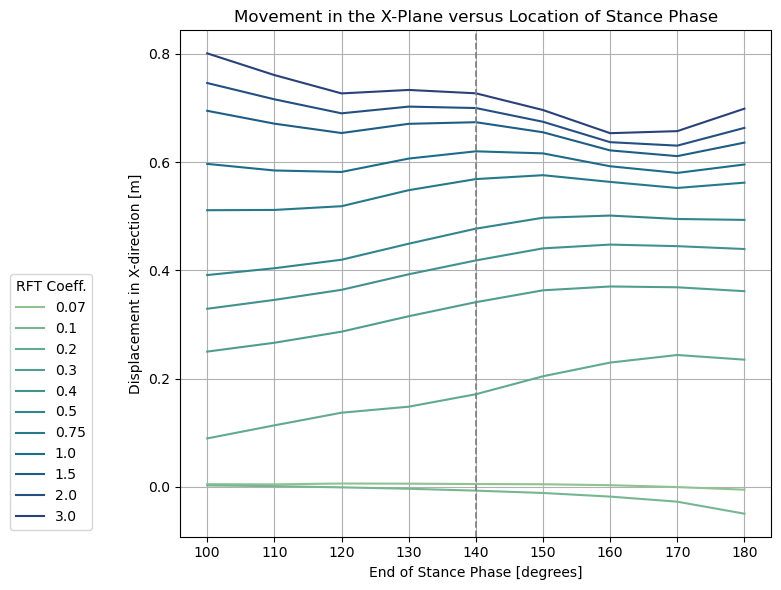

In [17]:
coeff_02 = [0.07,0.10,0.20,0.30,0.40,0.50,0.75,1.00,1.50,2.00,3.00]
#[0.07,0.10,0.20,0.30,0.40,0.50,0.75,1.00,1.50,2.00,3.00,4.00,10.00]
plt.figure(figsize=(8, 6))
start_stance = [100,110,120,130,140,150,160,170,180]

colors_04 = sns.color_palette("crest", n_colors=len(coeff_02))
for z,cl in zip(coeff_02,colors_04):
    results_z = []
    for start_angle in start_stance:
        stance_speed = glob.glob(os.path.join(path, f"*start_{start_angle:.2f}_rft_{z:.2f}.csv"))
        for a in stance_speed:
            df = pd.read_csv(a)
            x_pos = df['X [m]']
            #taking last integer in the df and subtracting it against the first
            x_displacement = x_pos.iloc[-1] - x_pos.iloc[0]

            #pairing displacement w/ stiffness values
            filename = os.path.basename(a)
            numbers = re.findall(r"\d+\.?\d*",filename)
            stance_step = float(numbers[0])
            results_z.append((stance_step , x_displacement , filename))

        # optional block for organizing the legend in order of stiffness
    results_z.sort(key=lambda x: x[0])   
    speeds = [r[0] for r in results_z]
    displacements = [r[1] for r in results_z]
    labels = [r[2] for r in results_z]

    sns.lineplot(x=speeds, y=displacements,linewidth = 1.5,label=f"{z}",color=cl)
#x_max = [170,]
#plt.scatter(x_max, y_max, color='red', marker='o', s=100)
plt.axvline(x=140, color='grey', linestyle='--', linewidth=1.25)
plt.xlabel("End of Stance Phase [degrees]")
plt.ylabel("Displacement in X-direction [m]")
plt.title("Movement in the X-Plane versus Location of Stance Phase")
plt.legend(loc="lower left",bbox_to_anchor=(-0.3, 0),title="RFT Coeff.")
plt.grid(True)
plt.tight_layout()
plt.show()
#this angle is actually where the phase ends so the smaller angles shift the stance phase sooner in the 

In [ ]:
# stance step
#[0.16,0.20,0.25,0.314285714286,0.4,0.52,0.7,0.127272727273,0.1,0.0769230769231,0.0571428571429,0.04,0.025 ]

#swing step
#[0.56,0.60,0.65,0.714285714286,0.8,0.92,1,1,0.527272727273,0.6,0.476923076923,0.457142857143,0.44,0.425]